# AI for Chemistry — Week 01, Session B
## NumPy + matplotlib workshop: arrays, spectra and equations of state

**Course:** AI for Chemistry · **Session:** 01B (hands-on workshop, 2.0 h) ·
**Runtime:** < 20 s, no GPU.

### Suggested timing (solo study, ~110 min)

| Section | Topic | Time |
|--------:|-------|-----:|
| 0 | Setup | 3 min |
| 1 | Arrays and vectorised maths | 20 min |
| 2 | Broadcasting and the Beer–Lambert law | 20 min |
| 3 | Boolean masks and axis-wise aggregation (peak picking) | 20 min |
| 4 | Loading data and plotting a spectrum | 15 min |
| 5 | Equation-of-state isotherms | 12 min |
| 6 | Exercises (4) + mini-challenge | 25 min |

### Learning objectives
1. Create NumPy arrays (`array`, `arange`, `linspace`, `zeros`) and apply
   vectorised arithmetic and `numpy` maths functions. *(LO1)*
2. Use broadcasting to combine arrays of different shapes; explain the shape
   rules. *(LO1)*
3. Select and summarise data with boolean masks and axis-wise reductions
   (`sum`, `mean`, `max` with `axis=`). *(LO1)*
4. Load numeric data with `np.loadtxt` and draw labelled matplotlib figures
   (line, scatter, subplots); fit a straight line with `np.polyfit`. *(LO1)*

### Prerequisites — before this notebook you should be able to
- Everything from Week 01A: variables, lists, `for` loops, `if`, functions,
  reading a `.csv` by hand.
- Recall the **Beer–Lambert law** $A = \varepsilon c \ell$ and the
  **ideal gas law** $PV = nRT$ from first-year chemistry.

### How to use this notebook (solo study)
As in 01A: read each markdown cell, run the code cell below it, compare the
output with the "what to look for" note, and clear every **✅ Check yourself**
cell before moving on. Figures are saved into `../slides/figures/` for reuse in
the lecture deck. This is the **solutions** notebook.


---
## 0. Setup

We import NumPy (conventionally `np`) and matplotlib's `pyplot` (as `plt`), and
locate the datasets folder exactly as in 01A. We also create the figure output
folder for the slide deck.

**What to look for:** version numbers print, and both data files report `OK`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(0xC0FFEE)          # fixed course-wide seed for reproducibility

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-01_python-bootcamp" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("numpy", np.__version__)
for f in ["ir_spectrum_synthetic.csv", "alkanes.csv"]:
    print(f"{f:28s}", "OK" if (DATA / f).is_file() else "MISSING")


numpy 2.4.6
ir_spectrum_synthetic.csv    OK
alkanes.csv                  OK


> **Common errors — Setup**
> - `ModuleNotFoundError: No module named 'numpy'` — the notebook is not running
>   in the `ai4chem` environment. Select that kernel (top-right in Jupyter).
> - Plots not showing — in classic notebooks add `%matplotlib inline`; in
>   JupyterLab it works out of the box.


---
## 1. Arrays and vectorised maths

A **NumPy array** stores many numbers of one type in a contiguous block, so
whole-array maths runs in fast compiled loops instead of slow Python ones. This
is the foundation every ML library is built on.

- `np.array([...])` — from a list
- `np.arange(start, stop, step)` — like `range`, `stop` excluded, step may be
  fractional
- `np.linspace(start, stop, n)` — `n` evenly spaced points, `stop` **included**
- `np.zeros(n)`, `np.ones(n)` — pre-filled arrays

Chemistry anchor: a **wavenumber axis** $\tilde\nu$ (cm$^{-1}$) and the two
quantities derived from it — wavelength $\lambda = 1/\tilde\nu$ and photon energy

$$E = h c \tilde\nu.$$

**What to look for:** `nu` has 7 evenly spaced values from 400 to 4000; the
energy of a 4000 cm$^{-1}$ photon is about $7.9\times10^{-20}$ J.


In [2]:
h = 6.626_070_15e-34      # J s   (Planck constant, exact SI)
c = 2.997_924_58e10       # cm/s  (speed of light in cm/s to match cm^-1)

nu = np.linspace(400, 4000, 7)          # wavenumber, cm^-1
wavelength_um = 1.0 / nu * 1e4          # cm -> micrometre (1 cm = 1e4 um)
photon_E = h * c * nu                   # J, elementwise (vectorised)

print("nu        :", nu)
print("lambda/um :", np.round(wavelength_um, 2))
print("E/J       :", photon_E)


nu        : [ 400. 1000. 1600. 2200. 2800. 3400. 4000.]
lambda/um : [25.   10.    6.25  4.55  3.57  2.94  2.5 ]
E/J       : [7.94578343e-21 1.98644586e-20 3.17831337e-20 4.37018089e-20
 5.56204840e-20 6.75391591e-20 7.94578343e-20]


Vectorised operations act on every element at once. Compare the "NumPy way"
with the equivalent Python loop — same answer, but the array version is shorter
and, on large data, far faster.

**What to look for:** the two results are identical (`allclose` prints `True`).


In [3]:
loop_result = []
for value in nu:
    loop_result.append(h * c * value)

print("match:", np.allclose(np.array(loop_result), photon_E))


match: True


> **Common errors — Section 1**
> - `np.arange(0, 1, 0.1)` sometimes gives 10 or 11 points due to floating-point
>   rounding — prefer `linspace` when the count matters.
> - Mixing an array with a list in `+` may build an object array or error; keep
>   data in arrays.
> - Wrong `c`: use `2.998e10` cm/s here (not m/s) so units cancel with cm$^{-1}$.


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. The 4000 cm⁻¹ photon energy is ≈ 7.95 × 10⁻²⁰ J.


In [4]:
# --- checkpoint (do not edit) ---
assert nu.shape == (7,)
assert np.isclose(nu[0], 400) and np.isclose(nu[-1], 4000)
assert np.isclose(photon_E[-1], h * c * 4000)
assert np.isclose(photon_E[-1], 7.949e-20, rtol=1e-3)
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. Why does `linspace(400, 4000, 7)` give a spacing of 600 cm$^{-1}$, not
   4000/7?
2. If you needed 0.5 cm$^{-1}$ resolution from 400 to 4000, which constructor
   would you use and how many points is that?


**Answers**


1. `linspace` includes **both** endpoints, so it places 7 points with 6 gaps:
   spacing $= (4000-400)/(7-1) = 600$.
2. `np.arange(400, 4000.5, 0.5)` (add half a step to the stop so 4000 is
   included), giving $(4000-400)/0.5 + 1 = 7201$ points.


---
## 2. Broadcasting and the Beer–Lambert law

**Broadcasting** lets NumPy combine arrays of different shapes by virtually
stretching size-1 dimensions. Rule: line the shapes up from the right; each
dimension must be **equal** or **one of them is 1**.

Chemistry anchor: **Beer–Lambert**, $A = \varepsilon\, c\, \ell$. Suppose we
measure a set of standards at several wavelengths. With molar absorptivities
$\varepsilon_j$ (one per wavelength, shape `(1, nwave)`) and concentrations
$c_i$ (one per sample, shape `(nsamp, 1)`), the full absorbance table
$A_{ij} = \varepsilon_j c_i \ell$ comes from a single multiplication.

**What to look for:** `A` has shape `(4, 3)` — 4 samples × 3 wavelengths — built
from a `(4,1)` and a `(1,3)` array without any loop.


In [5]:
path_length = 1.0                                   # cm (standard cuvette)
conc = np.array([1.0e-5, 2.0e-5, 4.0e-5, 8.0e-5])   # mol/L, 4 standards
eps = np.array([18_000.0, 9_500.0, 400.0])          # L/(mol cm), 3 wavelengths

A = conc[:, None] * eps[None, :] * path_length      # (4,1)*(1,3) -> (4,3)
print("conc shape :", conc[:, None].shape)
print("eps shape  :", eps[None, :].shape)
print("A shape    :", A.shape)
print(np.round(A, 3))


conc shape : (4, 1)
eps shape  : (1, 3)
A shape    : (4, 3)
[[0.18  0.095 0.004]
 [0.36  0.19  0.008]
 [0.72  0.38  0.016]
 [1.44  0.76  0.032]]


Absorbance relates to transmittance by $T = 10^{-A}$ (and %T $= 100\,T$). This
is another vectorised, elementwise operation over the whole table.

**What to look for:** the most concentrated sample at the strongest wavelength
($A \approx 1.44$) transmits only a few per cent of the light.


In [6]:
T = 10.0 ** (-A)                 # transmittance, elementwise
print("min %T:", round(100 * T.min(), 2), "  max %T:", round(100 * T.max(), 2))


min %T: 3.63   max %T: 99.08


> **Common errors — Section 2**
> - `ValueError: operands could not be broadcast together with shapes (4,) (3,)`
>   — you forgot to add the `None` (newaxis) so the shapes are `(4,1)` and
>   `(1,3)`.
> - `A ** -1` vs `10 ** -A`: transmittance is `10**(-A)`, not `1/A`.
> - Very large `A` gives `T` underflow to 0.0 — physically fine (opaque).


### ✅ Check yourself — Section 2

Prints `Section 2 OK`. `A[3,0] == 1.44`; every transmittance is in (0, 1].


In [7]:
# --- checkpoint (do not edit) ---
assert A.shape == (4, 3)
assert np.isclose(A[3, 0], 8.0e-5 * 18_000.0 * 1.0)     # 1.44
assert np.isclose(A[3, 0], 1.44)
assert np.all((T > 0) & (T <= 1))
assert np.isclose(T[0, 2], 10 ** (-A[0, 2]))
print("Section 2 OK")


Section 2 OK


**Conceptual questions**


1. Beer–Lambert is linear in $c$. Name one chemical reason it curves at high
   concentration.
2. What shape would `conc[:, None] + eps` have, and is that meaningful here?


**Answers**


1. At high $c$ the analyte molecules interact (shifting $\varepsilon$),
   refractive index changes, or stray light and finite spectrometer bandwidth
   flatten the apparent absorbance — so the calibration bends.
2. `(4, 3)` by broadcasting, but *adding* an absorptivity to a concentration is
   dimensionally meaningless; broadcasting will happily do nonsense, so the
   physics is your responsibility.


---
## 3. Boolean masks and axis-wise aggregation — peak picking

Load the synthetic IR spectrum and find its absorption bands. Two ideas:

* A **boolean mask** `spectrum > 0.3` is an array of `True`/`False`; indexing
  with it keeps only the elements where it is `True`.
* A point is a **local maximum** if it exceeds both neighbours. We express that
  by comparing three slices of the array against each other — no loop.

**What to look for:** six bands are found near
1050, 1250, 1450, 1715, 2950 and 3350 cm$^{-1}$ — the C–O, skeletal, CH bend,
C=O, C–H and O–H regions.


In [8]:
spec = np.loadtxt(DATA / "ir_spectrum_synthetic.csv", delimiter=",")
wn, absb = spec[:, 0], spec[:, 1]        # wavenumber, absorbance columns
print("loaded", spec.shape, "-> wavenumber", wn[0], "to", wn[-1], "cm^-1")

centre = absb[1:-1]                       # drop first/last so neighbours exist
is_peak = (centre > absb[:-2]) & (centre > absb[2:]) & (centre > 0.3)
peak_wn = wn[1:-1][is_peak]              # wavenumbers where the mask is True
print("bands (cm^-1):", peak_wn)


loaded (1801, 2) -> wavenumber 400.0 to 4000.0 cm^-1
bands (cm^-1): [1050. 1250. 1450. 1714. 2950. 3350.]


Now some **axis-wise aggregation**. Split the spectrum into the classic regions
and get the mean absorbance in each. Stacking the region arrays into a 2-D array
lets one `.mean(axis=1)` call do all regions at once.

**What to look for:** the carbonyl region (1650–1800) has the highest mean
absorbance; the 1800–2700 "quiet zone" has the lowest.


In [9]:
regions = {
    "fingerprint 400-1500": (wn >= 400) & (wn < 1500),
    "carbonyl 1650-1800":   (wn >= 1650) & (wn < 1800),
    "quiet 1800-2700":      (wn >= 1800) & (wn < 2700),
    "X-H 2700-3700":        (wn >= 2700) & (wn < 3700),
}
for label, mask in regions.items():
    print(f"{label:24s} mean A = {absb[mask].mean():.3f}   n = {mask.sum()}")


fingerprint 400-1500     mean A = 0.108   n = 550
carbonyl 1650-1800       mean A = 0.347   n = 75
quiet 1800-2700          mean A = 0.033   n = 450
X-H 2700-3700            mean A = 0.239   n = 500


> **Common errors — Section 3**
> - `and` / `or` on arrays raises "truth value ... is ambiguous" — use the
>   elementwise `&` / `|`, and parenthesise each comparison.
> - Off-by-one: comparing `absb[1:]` with `absb[:-1]` gives arrays of *different*
>   length; align them by slicing all three (`[:-2]`, `[1:-1]`, `[2:]`).
> - A boolean mask must be the **same length** as the axis it indexes.


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. Exactly six bands, each within 5 cm⁻¹ of 1050/1250/1450/1715/2950/3350.


In [10]:
# --- checkpoint (do not edit) ---
assert wn.shape == absb.shape == (1801,)
assert len(peak_wn) == 6
# bands within 5 cm^-1 of the expected group frequencies
expected = np.array([1050, 1250, 1450, 1715, 2950, 3350])
assert np.all(np.abs(np.sort(peak_wn) - expected) <= 5)
assert absb[regions["carbonyl 1650-1800"]].mean() > absb[regions["quiet 1800-2700"]].mean()
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. Our detector calls a point a peak only if it *strictly* exceeds both
   neighbours. What kind of real spectral feature would this miss?
2. Why threshold at `0.3` rather than reporting every local maximum?


**Answers**


1. A flat-topped or noisy band where two adjacent points are equal at the
   maximum (a plateau) — neither strictly exceeds the other. Real peak
   finders smooth first or allow `>=` on one side.
2. Noise and baseline wobble produce many tiny local maxima; a height (or
   prominence) threshold keeps only chemically meaningful bands.


---
## 4. Loading data and plotting a spectrum

matplotlib basics: `plt.subplots()` gives a figure and axes; `ax.plot(x, y)`
draws a line; always label axes and add a legend; `fig.savefig(..., dpi=200)`
writes a file. IR spectra are conventionally plotted with the wavenumber axis
**decreasing** left to right.

**What to look for:** a spectrum with a sharp carbonyl spike near 1715 cm$^{-1}$
and a broad O–H hump near 3350 cm$^{-1}$; a PNG is written to
`../slides/figures/`.


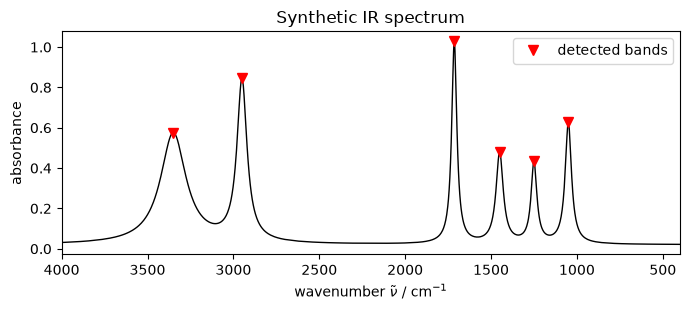

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(wn, absb, lw=1.0, color="k")
ax.plot(peak_wn, absb[np.isin(wn, peak_wn)], "rv", ms=7, label="detected bands")
ax.set_xlim(4000, 400)                     # reversed axis (IR convention)
ax.set_xlabel(r"wavenumber $\tilde\nu$ / cm$^{-1}$")
ax.set_ylabel("absorbance")
ax.set_title("Synthetic IR spectrum")
ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR / "ir_spectrum.png", dpi=200)
plt.show()


A two-panel figure with `plt.subplots(1, 2)`: absorbance and the corresponding
transmittance $T = 10^{-A}$ of the same spectrum.

**What to look for:** peaks in absorbance become dips in transmittance.


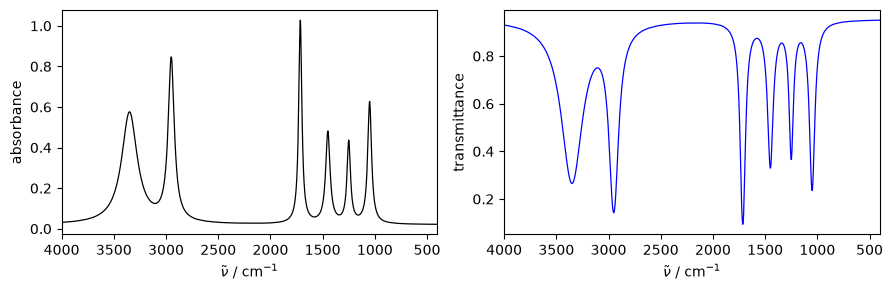

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharex=True)
axes[0].plot(wn, absb, "k", lw=0.9);           axes[0].set_ylabel("absorbance")
axes[1].plot(wn, 10 ** (-absb), "b", lw=0.9);  axes[1].set_ylabel("transmittance")
for a_ in axes:
    a_.set_xlim(4000, 400)
    a_.set_xlabel(r"$\tilde\nu$ / cm$^{-1}$")
fig.tight_layout()
fig.savefig(FIGDIR / "ir_absorbance_vs_transmittance.png", dpi=200)
plt.show()


> **Common errors — Section 4**
> - Nothing appears / blank figure — you called `plt.show()` before plotting, or
>   in a script forgot it entirely.
> - `ax.plot` with x and y of different length raises `ValueError`.
> - Overlapping labels — `fig.tight_layout()` usually fixes it.


### ✅ Check yourself — Section 4

Prints `Section 4 OK`; two PNG files now exist under `lectures/week-01_python-bootcamp/slides/figures/`.


In [13]:
# --- checkpoint (do not edit) ---
assert (FIGDIR / "ir_spectrum.png").is_file()
assert (FIGDIR / "ir_absorbance_vs_transmittance.png").is_file()
print("Section 4 OK")


Section 4 OK


**Conceptual questions**


1. Why plot IR spectra with wavenumber decreasing to the right?
2. Transmittance and absorbance carry the same information. When is each the
   more natural choice?


**Answers**


1. Historical convention from dispersive instruments that scanned high to low
   wavenumber; keeping it lets chemists compare spectra by eye across decades
   of literature.
2. Transmittance is what the detector actually measures and is intuitive for
   "how much light got through"; absorbance is linear in concentration
   (Beer–Lambert), so it is used for quantitative work.


---
## 5. Equation-of-state isotherms

Compare the **ideal gas** law with the **van der Waals** equation for CO$_2$ at
300 K:

$$P_\text{ideal} = \frac{nRT}{V}, \qquad
  P_\text{vdW} = \frac{nRT}{V - nb} - \frac{a n^2}{V^2}.$$

The constants $a = 3.640\ \text{L}^2\,\text{bar}\,\text{mol}^{-2}$ and
$b = 0.04267\ \text{L}\,\text{mol}^{-1}$ are tabulated for CO$_2$.
`TODO(verify)` against a primary source before assessed use.

**What to look for:** the two curves converge as $V$ grows (to within a couple
of per cent by $V = 6$ L); at small $V$ the van der Waals pressure sits *below*
the ideal value because the attraction term $-an^2/V^2$ dominates.


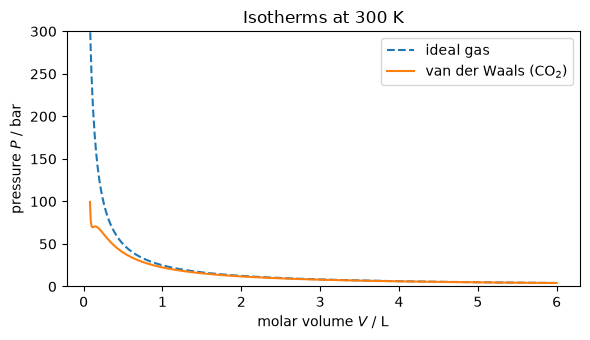

In [14]:
R = 0.083_145            # L bar / (mol K)
T_iso, n = 300.0, 1.0    # K, mol
a, b = 3.640, 0.04267    # CO2 van der Waals constants (L^2 bar/mol^2, L/mol)

V = np.linspace(0.08, 6.0, 600)               # molar volume range, L
P_ideal = n * R * T_iso / V
P_vdw = n * R * T_iso / (V - n * b) - a * n**2 / V**2
frac_diff = np.abs(P_vdw - P_ideal) / P_ideal  # fractional deviation vs V

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(V, P_ideal, "--", label="ideal gas")
ax.plot(V, P_vdw, "-", label="van der Waals (CO$_2$)")
ax.set_xlabel("molar volume $V$ / L"); ax.set_ylabel("pressure $P$ / bar")
ax.set_ylim(0, 300); ax.set_title("Isotherms at 300 K"); ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR / "vdw_isotherms.png", dpi=200)
plt.show()


> **Common errors — Section 5**
> - `RuntimeWarning: divide by zero` if `V` includes `n*b` exactly — keep the
>   lower limit safely above `b`.
> - Wrong `R`: match its units to the pressure/volume units you want
>   (`0.083145 L bar / mol K` here).


### ✅ Check yourself — Section 5

Prints `Section 5 OK`. The fractional gas-law deviation falls below 3% by V = 6 L and grows large at small V.


In [15]:
# --- checkpoint (do not edit) ---
assert P_ideal.shape == P_vdw.shape == (600,)
# fractional deviation shrinks as V grows (curves converging)
assert frac_diff[-1] < frac_diff[len(V) // 4]
assert frac_diff[-1] < 0.03
# van der Waals predicts a lower pressure than ideal somewhere at small V
assert np.any(P_vdw < P_ideal)
assert (FIGDIR / "vdw_isotherms.png").is_file()
print("Section 5 OK")


Section 5 OK


**Conceptual questions**


1. Which van der Waals term dominates the deviation at moderately small volume,
   and what molecular property does it represent?
2. Above the critical temperature the isotherm is monotonic. What changes
   below it?


**Answers**


1. The $-an^2/V^2$ term (intermolecular attraction) pulls the pressure below
   the ideal value first; the $nb$ excluded-volume term dominates only once
   $V$ approaches $nb$.
2. Below $T_c$ the van der Waals isotherm develops a non-physical
   "wiggle" (region of $\partial P/\partial V > 0$), which the Maxwell
   equal-area construction replaces with a flat liquid–vapour coexistence
   line.


---
## 6. Exercises

Four exercises then a mini-challenge. Blank bodies in the `_student` notebook;
the `assert` cells are identical in both versions.


### Exercise 1 — transmittance array *(easy, ~8 min)*

Write `to_percent_transmittance(absorbance)` returning $100 \times 10^{-A}$ as an
array, then apply it to `absb` (the IR spectrum) to get `pct_T`.

<details><summary>Show hint</summary>

One line: `return 100.0 * 10.0 ** (-absorbance)`. NumPy broadcasts the scalar
over the array.
</details>


In [16]:
def to_percent_transmittance(absorbance):
    """Percent transmittance from absorbance: 100 * 10**(-A)."""
    return 100.0 * 10.0 ** (-absorbance)

pct_T = to_percent_transmittance(absb)
print("min %T =", round(pct_T.min(), 2), " at", wn[pct_T.argmin()], "cm^-1")


min %T = 9.38  at 1714.0 cm^-1


In [17]:
# --- check your answer (do not edit) ---
assert pct_T.shape == absb.shape
assert np.isclose(pct_T.max(), 100.0 * 10 ** (-absb.min()))
assert np.isclose(to_percent_transmittance(np.array([0.0]))[0], 100.0)
assert np.isclose(to_percent_transmittance(np.array([1.0]))[0], 10.0)
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — band positions above a threshold *(medium, ~15 min)*

Write `find_bands(wavenumber, absorbance, threshold)` returning the array of
wavenumbers that are strict local maxima **and** above `threshold`. Reuse the
three-slice trick from Section 3. Test it at `threshold=0.5`.

<details><summary>Show hint</summary>

`centre = absorbance[1:-1]`; mask =
`(centre > absorbance[:-2]) & (centre > absorbance[2:]) & (centre > threshold)`;
return `wavenumber[1:-1][mask]`.
At 0.5 the weak C–O / skeletal bands drop out.
</details>


In [18]:
def find_bands(wavenumber, absorbance, threshold):
    """Wavenumbers of strict local maxima above `threshold`."""
    centre = absorbance[1:-1]
    mask = ((centre > absorbance[:-2]) & (centre > absorbance[2:])
            & (centre > threshold))
    return wavenumber[1:-1][mask]

strong_bands = find_bands(wn, absb, 0.5)
print("strong bands:", strong_bands)


strong bands: [1050. 1714. 2950. 3350.]


In [19]:
# --- check your answer (do not edit) ---
assert set(np.round(find_bands(wn, absb, 0.3)).astype(int)) == {1050, 1250, 1450, 1714, 2950, 3350}
assert set(np.round(strong_bands).astype(int)) == {1050, 1714, 2950, 3350}
assert find_bands(wn, absb, 2.0).size == 0
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — row-normalise a spectral matrix *(medium, ~15 min)*

`build_replicates` (given) makes a `(5, 1801)` matrix of five noisy copies of the
spectrum. Write `normalise_rows(mat)` that divides **each row** by that row's
maximum, so every spectrum peaks at 1. Use broadcasting with `keepdims=True`.

<details><summary>Show hint</summary>

`row_max = mat.max(axis=1, keepdims=True)` has shape `(5, 1)`; then
`return mat / row_max` broadcasts correctly.
</details>


In [20]:
def build_replicates(base, n=5, noise=0.02, rng=np.random.default_rng(0xC0FFEE)):
    """n noisy replicates of a 1-D spectrum -> shape (n, len(base))."""
    return base[None, :] + rng.normal(0.0, noise, size=(n, base.size))

def normalise_rows(mat):
    """Scale each row so its maximum is 1."""
    row_max = mat.max(axis=1, keepdims=True)     # shape (n, 1)
    return mat / row_max

reps = build_replicates(absb)
reps_norm = normalise_rows(reps)
print("row maxima after normalising:", np.round(reps_norm.max(axis=1), 6))


row maxima after normalising: [1. 1. 1. 1. 1.]


In [21]:
# --- check your answer (do not edit) ---
assert reps.shape == (5, 1801)
assert reps_norm.shape == (5, 1801)
assert np.allclose(reps_norm.max(axis=1), 1.0)
# normalisation must not change the position of each row's peak
assert np.array_equal(reps.argmax(axis=1), reps_norm.argmax(axis=1))
print("Exercise 3 OK")


Exercise 3 OK


### Exercise 4 — molar absorptivity by linear fit *(medium, ~15 min)*

`calib` (given) is measured absorbance for six standards of known concentration
at one wavelength, path length 1 cm. Fit $A = \varepsilon \ell c$ with
`np.polyfit(conc, A, 1)` and return `eps` (the slope, since $\ell = 1$) and the
intercept.

<details><summary>Show hint</summary>

`slope, intercept = np.polyfit(conc_std, calib, 1)`. The true value used to make
the data is 15 000 L mol⁻¹ cm⁻¹, so expect ~15 000.
</details>


In [22]:
conc_std = np.array([0.0, 1e-5, 2e-5, 3e-5, 4e-5, 5e-5])       # mol/L
_rng = np.random.default_rng(0xC0FFEE)
calib = 15_000.0 * 1.0 * conc_std + _rng.normal(0, 0.004, conc_std.size)

def fit_beer_lambert(conc, a_vals):
    """Return (epsilon, intercept) from a straight-line fit of A vs c (l = 1)."""
    slope, intercept = np.polyfit(conc, a_vals, 1)
    return slope, intercept

eps_fit, intercept_fit = fit_beer_lambert(conc_std, calib)
print(f"epsilon = {eps_fit:.0f} L/(mol cm),  intercept = {intercept_fit:.4f}")


epsilon = 15028 L/(mol cm),  intercept = 0.0014


In [23]:
# --- check your answer (do not edit) ---
assert abs(eps_fit - 15_000) < 1_500, "slope should be within 10% of 15000"
assert abs(intercept_fit) < 0.02, "intercept should be near zero"
print("Exercise 4 OK")


Exercise 4 OK


### 🏁 Mini-challenge — pick the best analytical wavelength *(~20 min)*

You are given `A_multi`, a `(6, 4)` array: absorbance of the same six standards
(`conc_std`) at **four** candidate wavelengths, plus the true molar
absorptivities `eps_true`. A good analytical wavelength has a **large slope**
(sensitive) and a **high $R^2$** (linear).

Write `best_wavelength(conc, A_multi)` that, for each column, fits a line and
computes $R^2$, then returns `(index, slope, r2)` for the column with the
largest slope. Plot that column's calibration line with the fit overlaid and
save it to `FIGDIR / "beer_lambert_fit.png"`.

$R^2 = 1 - \dfrac{\sum (A_i - \hat A_i)^2}{\sum (A_i - \bar A)^2}$.

<details><summary>Show hint</summary>

Loop over `range(A_multi.shape[1])`; `slope, intc = np.polyfit(conc, col, 1)`;
`pred = slope*conc + intc`; `r2 = 1 - ss_res/ss_tot`. Track the column with the
biggest `slope`.
</details>


In [24]:
# given data for the mini-challenge (do not edit)
eps_true = np.array([15_000.0, 42_000.0, 800.0, 6_500.0])       # L/(mol cm)
_rng2 = np.random.default_rng(0xBEEF)
A_multi = (conc_std[:, None] * eps_true[None, :] * 1.0
           + _rng2.normal(0.0, 0.006, size=(conc_std.size, eps_true.size)))
print("A_multi shape:", A_multi.shape)


A_multi shape: (6, 4)


Now implement `best_wavelength` and make the calibration plot.


best channel: index 1,  epsilon ~ 42261,  R2 = 0.9999


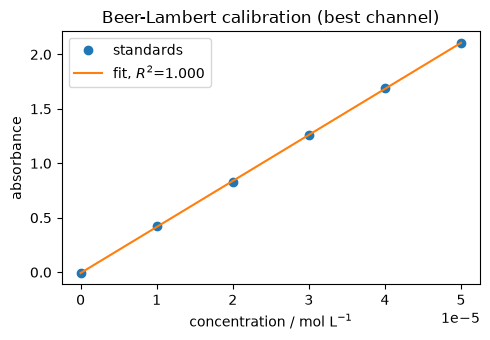

In [25]:
def best_wavelength(conc, A_multi):
    """Return (col_index, slope, r2) for the most sensitive linear channel."""
    best = (None, -np.inf, None)
    for j in range(A_multi.shape[1]):
        col = A_multi[:, j]
        slope, intc = np.polyfit(conc, col, 1)
        pred = slope * conc + intc
        ss_res = np.sum((col - pred) ** 2)
        ss_tot = np.sum((col - col.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot
        if slope > best[1]:
            best = (j, slope, r2)
    return best

j_best, slope_best, r2_best = best_wavelength(conc_std, A_multi)
print(f"best channel: index {j_best},  epsilon ~ {slope_best:.0f},  R2 = {r2_best:.4f}")

slope, intc = np.polyfit(conc_std, A_multi[:, j_best], 1)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(conc_std, A_multi[:, j_best], "o", label="standards")
ax.plot(conc_std, slope * conc_std + intc, "-", label=f"fit, $R^2$={r2_best:.3f}")
ax.set_xlabel("concentration / mol L$^{-1}$"); ax.set_ylabel("absorbance")
ax.set_title("Beer-Lambert calibration (best channel)"); ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR / "beer_lambert_fit.png", dpi=200)
plt.show()


In [26]:
# --- check your answer (do not edit) ---
assert j_best == 1, "channel 1 (eps_true 42000) has by far the largest slope"
assert abs(slope_best - 42_000) < 4_000
assert r2_best > 0.99
assert (FIGDIR / "beer_lambert_fit.png").is_file()
print("Mini-challenge OK")


Mini-challenge OK


---
## Summary — what you learned

- **Arrays**: `array`, `arange`, `linspace`, `zeros`; vectorised maths replaces
  Python loops and is far faster.
- **Broadcasting**: combine `(m,1)` and `(1,n)` arrays into `(m,n)` — used to
  build a Beer–Lambert absorbance table in one line.
- **Boolean masks** and **axis-wise reductions** (`mean`/`max`/`sum` with
  `axis=`, `keepdims=`) — used for peak picking and region statistics.
- **matplotlib**: `subplots`, `plot`, axis labels, legends, reversed axes,
  `savefig`; straight-line fitting with `np.polyfit` and an $R^2$ calculation.

Week 02 moves from raw arrays to **pandas dataframes** and introduces
**RDKit** for turning molecules into numbers.


## Further reading (course source list only)

- SciCompforChemists ch. 4 (NumPy) and ch. 3 (matplotlib):
  <https://weisscharlesj.github.io/SciCompforChemists/notebooks/chapter_04/chap_04_notebook.html>,
  <https://weisscharlesj.github.io/SciCompforChemists/notebooks/chapter_03/chap_03_notebook.html>
- MolSSI lesson 04 (tabular data) and lesson 05 (plotting):
  <https://education.molssi.org/python_scripting_cms/04-tabular_data/index.html>,
  <https://education.molssi.org/python_scripting_cms/05-plotting/index.html>
- Colab alternative (EPFL *AI for Chemistry* 01c, plotting essentials):
  <https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/01%20-%20Basics/01c_python_essentials_plotting.ipynb>


## Attribution

Original teaching material for *AI for Chemistry*, adapted and rewritten from:

- **Scientific Computing for Chemists with Python** (C. J. Weiss) — NumPy and
  matplotlib pedagogy, spectroscopy framing. CC-BY-NC-SA 4.0.
  <https://github.com/weisscharlesj/SciCompforChemists>
- **MolSSI Python Scripting for Computational Molecular Science** — tabular-data
  and plotting lessons. CC-BY 4.0.
  <https://education.molssi.org/python_scripting_cms/>
- **EPFL CH-457 *AI for Chemistry*** (Schwaller group) — course framing.
  MIT licence. <https://github.com/schwallergroup/ai4chem_course>

Datasets: `ir_spectrum_synthetic.csv` is generated (sum of Lorentzians at
documented group frequencies) — **not measured data**. van der Waals constants
for CO$_2$ are tabulated values marked `TODO(verify)`. No verbatim text is
reproduced from the sources above.
